In [30]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
t=torch.tensor(7)
print(t)
print(t.ndim)
print(t.shape)
print(t.size)

tensor(7)
0
torch.Size([])
<built-in method size of Tensor object at 0x7837e0990690>


In [3]:
t=torch.tensor([1,2,3])
print(t)
t1=torch.zeros(size=(3,4))
print(t1)

tensor([1, 2, 3])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [4]:
creating_range=torch.arange(0,10);
to=torch.arange(start=0,end=10,step=1)
print(to)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [5]:
tens=torch.rand(10,3);
print(tens)
# Create a tensor
some_tensor = torch.rand(3, 4)

# Find out details about it
print(some_tensor)
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device tensor is stored on: {some_tensor.device}") # will default to CPU

tensor([[0.2760, 0.4936, 0.4331],
        [0.0014, 0.2363, 0.6496],
        [0.2770, 0.3165, 0.0605],
        [0.8797, 0.8150, 0.0651],
        [0.1066, 0.6624, 0.1929],
        [0.2799, 0.0805, 0.5343],
        [0.8776, 0.2751, 0.9974],
        [0.9714, 0.5690, 0.9362],
        [0.7950, 0.3757, 0.6305],
        [0.2881, 0.9776, 0.6943]])
tensor([[0.6228, 0.5127, 0.0059, 0.7904],
        [0.4568, 0.6998, 0.8640, 0.4009],
        [0.2265, 0.7708, 0.1654, 0.0133]])
Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [6]:
mul=torch.matmul(tens,some_tensor)
print(mul)

tensor([[0.4955, 0.8208, 0.4998, 0.4219],
        [0.2560, 0.6669, 0.3117, 0.1045],
        [0.3308, 0.4101, 0.2851, 0.3466],
        [0.9349, 1.0715, 0.7201, 1.0229],
        [0.4127, 0.6669, 0.6049, 0.3524],
        [0.3321, 0.6117, 0.1596, 0.2606],
        [0.8981, 1.4112, 0.4078, 0.8173],
        [1.0770, 1.6178, 0.6522, 1.0084],
        [0.8096, 1.1565, 0.4336, 0.7874],
        [0.7833, 1.3670, 0.9612, 0.6289]])


In [7]:
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float16)

tensor_B = torch.tensor([[7, 10],
                         [8, 11]], dtype=torch.float16)

torch.matmul(tensor_A, tensor_B)

tensor([[ 23.,  32.],
        [ 53.,  74.],
        [ 83., 116.]], dtype=torch.float16)

In [10]:
print(tensor_A.T)
t_new=torch.tensor([[1,11,21]])
print(tensor_A.T*t_new)
print(torch.mm(tensor_A,tensor_B))

tensor([[1., 3., 5.],
        [2., 4., 6.]], dtype=torch.float16)
tensor([[  1.,  33., 105.],
        [  2.,  44., 126.]], dtype=torch.float16)
tensor([[ 23.,  32.],
        [ 53.,  74.],
        [ 83., 116.]], dtype=torch.float16)


In [9]:
# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input
                         out_features=6) # out_features = describes outer value
x = tensor_A.to(torch.float32) # Convert input tensor to float32
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 2])

Output:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


In [12]:
print(torch.cuda.is_available())#no gpu available
random_seed=0
a=torch.rand(size=(7,7))
print(a.shape,a.ndim,a)

False
torch.Size([7, 7]) 2 tensor([[0.2036, 0.2018, 0.2018, 0.9497, 0.6666, 0.9811, 0.0874],
        [0.0041, 0.1088, 0.1637, 0.7025, 0.6790, 0.9155, 0.2418],
        [0.1591, 0.7653, 0.2979, 0.8035, 0.3813, 0.7860, 0.1115],
        [0.2477, 0.6524, 0.6057, 0.3725, 0.7980, 0.8399, 0.1374],
        [0.2331, 0.9578, 0.3313, 0.3227, 0.0162, 0.2137, 0.6249],
        [0.4340, 0.1371, 0.5117, 0.1585, 0.0758, 0.2247, 0.0624],
        [0.1816, 0.9998, 0.5944, 0.6541, 0.0337, 0.1716, 0.3336]])


In [36]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]#first 10 values for both x and y


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [16]:
from torch import nn

In [18]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [24]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
print(list(model_0.parameters()))
list(model_0.modules())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


[LinearRegressionModel()]

In [26]:
list(model_0.state_dict().keys())

['weights', 'bias']

In [27]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [31]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

In [32]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

In [39]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Number of training samples of X_train:{len(X_train)}")
print(f"Predicted values:\n{y_preds}")
print(f"difference between pred and actual values:{X_train[:10]-X_test}")

Number of testing samples: 10
Number of predictions made: 10
Number of training samples of X_train:40
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])
difference between pred and actual values:tensor([[-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000],
        [-0.8000]])


In [41]:

loss_fn = torch.nn.L1Loss() #mean absolute ereor calculation
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [46]:
torch.manual_seed(42)
epochs=100;
train_loss_values=[]
test_loss_values=[]
epochs_done=[]
for epoch in range(epochs):
    model_0.train()
    y_pred=model_0(X_train);
    print(y_pred);
    loss=loss_fn(y_pred,y_train);
    optimizer.zero_grad();
    loss.backward();
    optimizer.step();
    with torch.inference_mode():
        test_pred=model_0(X_test);
        test_loss=loss_fn(test_pred,y_test);
        epochs_done.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

tensor([[0.3513],
        [0.3629],
        [0.3744],
        [0.3860],
        [0.3976],
        [0.4092],
        [0.4207],
        [0.4323],
        [0.4439],
        [0.4554],
        [0.4670],
        [0.4786],
        [0.4901],
        [0.5017],
        [0.5133],
        [0.5248],
        [0.5364],
        [0.5480],
        [0.5595],
        [0.5711],
        [0.5827],
        [0.5943],
        [0.6058],
        [0.6174],
        [0.6290],
        [0.6405],
        [0.6521],
        [0.6637],
        [0.6752],
        [0.6868],
        [0.6984],
        [0.7099],
        [0.7215],
        [0.7331],
        [0.7446],
        [0.7562],
        [0.7678],
        [0.7794],
        [0.7909],
        [0.8025]], grad_fn=<AddBackward0>)
Epoch: 0 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
tensor([[0.3503],
        [0.3619],
        [0.3735],
        [0.3851],
        [0.3967],
        [0.4083],
        [0.4199],
        [0.4315],
        [0.4431],
       

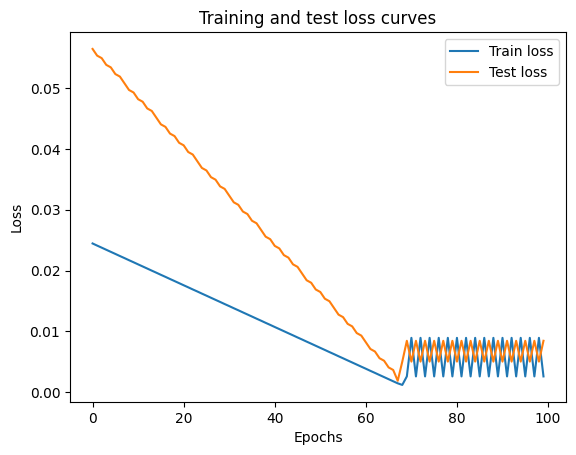

In [47]:
# Plot the loss curves
plt.plot(epochs_done, train_loss_values, label="Train loss")
plt.plot(epochs_done, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();